In [24]:
import os
from langchain_groq import ChatGroq
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings.fastembed import FastEmbedEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langgraph.graph import StateGraph,END,START
from pydantic import BaseModel
from typing import List
from dotenv import load_dotenv
load_dotenv()



True

In [12]:
docs = PyPDFLoader("Machine_learning.pdf").load()

In [14]:
chunks = RecursiveCharacterTextSplitter(chunk_size=1000 , chunk_overlap=200).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [15]:
len(chunks)

1121

In [16]:
# convert chunks into embeddings 
embeddings = FastEmbedEmbeddings(model="BAAI/bge-small-en-v1.5")

vector_store = FAISS.from_documents(chunks, embeddings)

In [20]:
vector_store.save_local("vectore_store")

In [21]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

## Query Search 

In [19]:
llm = ChatGroq(model="openai/gpt-oss-120b",api_key=os.getenv("GROQ_API_KEY"),temperature=0)

In [25]:
class State(BaseModel):
    query:str
    docs: List[Document]
    answer:str

In [27]:
# retrieve node 
def retrieve(state:State):
    query = state.query

    return {
        "docs": retriever.invoke(query)
    }


In [28]:
prompt = ChatPromptTemplate.from_messages(
    [
       ("system", "Answer only from the context. if not in context, say you don't know."),
       ("human", "Question: {question}\n\nContext:\n{context}"),

    ]
)

In [29]:
def generate(state:State):
    context = "\n\n".join(d.page_content for d in state.docs)
    output = (prompt|llm).invoke({"question":state.query, "context":context})

    return {
        "answer": output.content
    }

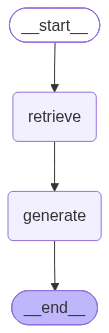

In [30]:
# ADD Graph 

graph = StateGraph(State)
graph.add_node("retrieve", retrieve)
graph.add_node("generate",generate)
graph.add_edge(START,"retrieve")
graph.add_edge("retrieve","generate")
graph.add_edge("generate",END)
app = graph.compile()

app